# Aliasing in Expert products

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

In [2]:
data_dir = '/work/uo0122/u241387/SWOT_SSH/diags_2024/'
ds_segments = xr.open_dataset(data_dir+'swot_aliased_202401.nc')
ds_segments

<xarray.Dataset> Size: 243MB
Dimensions:                        (segment: 148965, wavenumber: 63)
Coordinates:
  * segment                        (segment) int64 1MB 0 1 2 ... 148963 148964
  * wavenumber                     (wavenumber) float64 504B 0.0 0.004 ... 0.248
Data variables: (12/16)
    direct_psd                     (segment, wavenumber) float64 75MB ...
    aliased_psd                    (segment, wavenumber) float64 75MB ...
    total_psd                      (segment, wavenumber) float64 75MB ...
    lat_mean                       (segment) float64 1MB ...
    lat_min                        (segment) float64 1MB ...
    lat_max                        (segment) float64 1MB ...
    ...                             ...
    n_pixels                       (segment) int64 1MB ...
    valid_fraction                 (segment) float64 1MB ...
    gap_filled                     (segment) bool 149kB ...
    gap_fraction                   (segment) float64 1MB ...
    swath                          (segment) <U5 3MB ...
    segment_index                  (segment) int64 1MB ...

In [13]:
filename_expert = 'swot_segments_1000km_2deg_demean.nc'
ds_segments_expert= xr.open_dataset(DATA_DIR+DATA_SUBDIR+filename_expert)

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/PortableSSD/diags_2024/swot_segments_1000km_2deg_demean.nc'

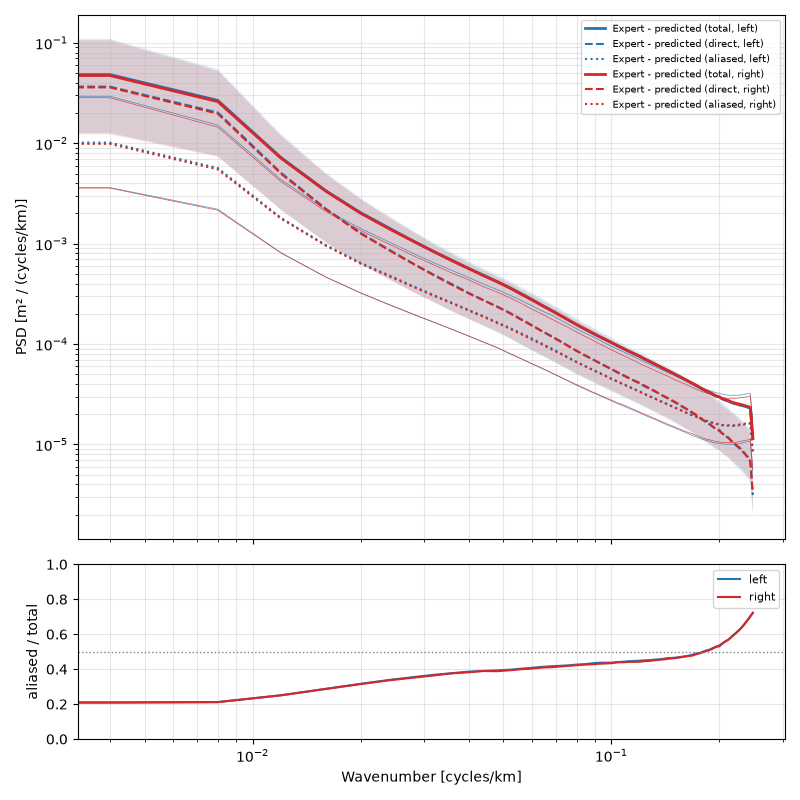

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    total_stack = direct_stack + aliased_stack
    
    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [25, 75], axis=0)
    aliased_median = np.nanmedian(aliased_stack, axis=0)
    aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [25, 75], axis=0)
    total_median = np.nanmedian(total_stack, axis=0)
    
    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, aliased_lo, c=c,lw=0.5,alpha=0.8)
    ax.loglog(k, aliased_hi, c=c,lw=0.5,alpha=0.8)
    ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, aliased_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()

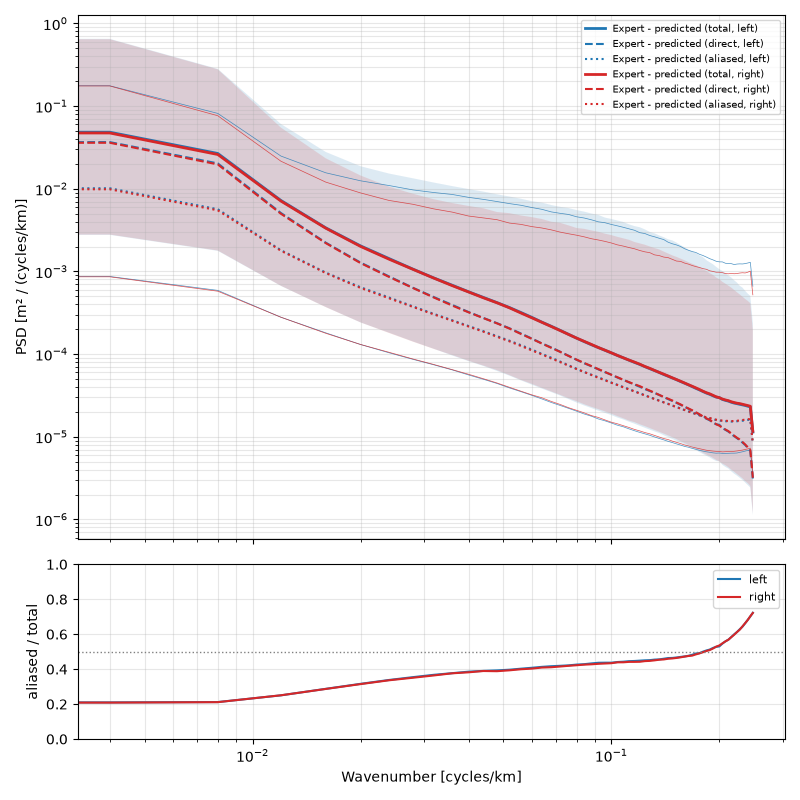

In [4]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    total_stack = direct_stack + aliased_stack
    
    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [5, 95], axis=0)
    aliased_median = np.nanmedian(aliased_stack, axis=0)
    aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [5, 95], axis=0)
    total_median = np.nanmedian(total_stack, axis=0)
    
    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, aliased_lo, c=c,lw=0.5,alpha=0.8)
    ax.loglog(k, aliased_hi, c=c,lw=0.5,alpha=0.8)
    ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, aliased_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()

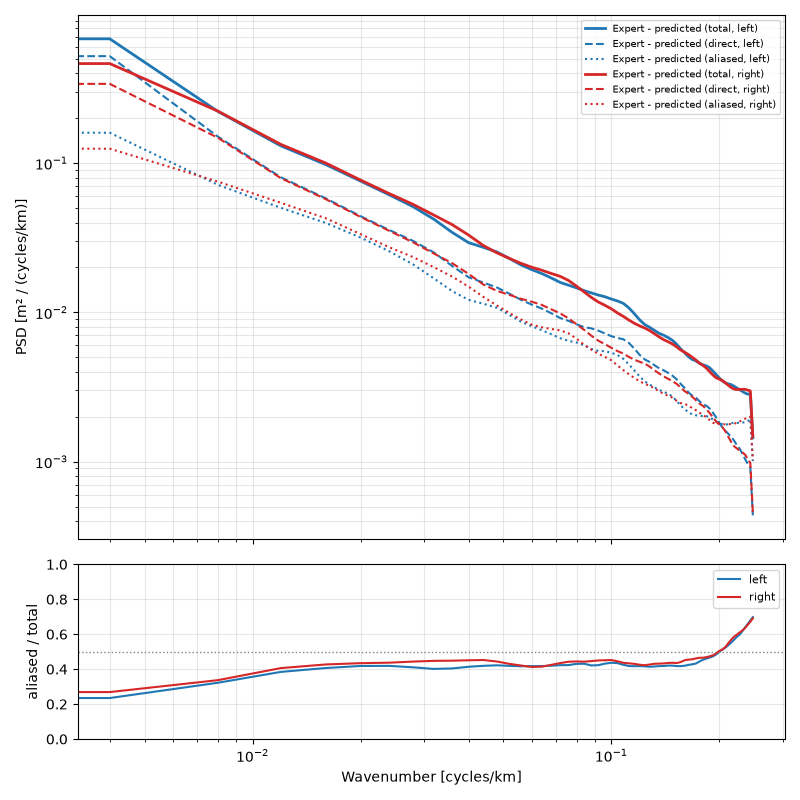

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    total_stack = direct_stack + aliased_stack
    
    direct_median = np.nanmean(direct_stack, axis=0)
    aliased_median = np.nanmean(aliased_stack, axis=0)
    total_median = np.nanmean(total_stack, axis=0)
    
    ax = axs[0]
    ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, aliased_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()

In [6]:
import seaborn as sns

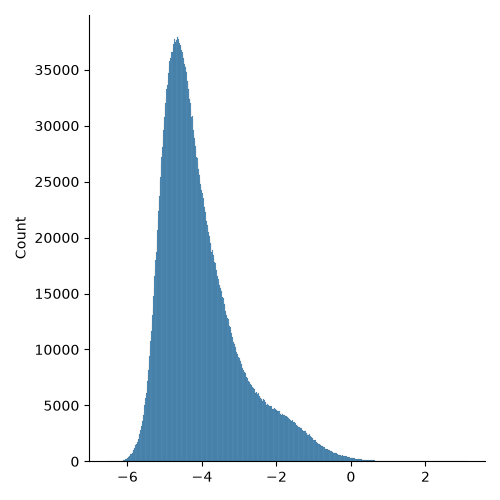

In [7]:
sns.displot(np.log10(direct_stack.flatten()))

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import xarray as xr
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_seg: int = 5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    direct_all = ds_segments['direct_psd'].values
    aliased_all = ds_segments['aliased_psd'].values
    total_all = ds_segments['total_psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n = [], [], []
    rows_direct, rows_aliased, rows_total = [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_direct.append(np.nanmean(direct_all[idxs, :], axis=0))
        rows_aliased.append(np.nanmean(aliased_all[idxs, :], axis=0))
        rows_total.append(np.nanmean(total_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_seg # * n_max

    direct_stack  = np.stack(rows_direct, axis=0)
    aliased_stack  = np.stack(rows_aliased, axis=0)
    total_stack  = np.stack(rows_total, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            direct_mean_psd=(['box', 'wavenumber'], direct_stack[keep],
                      {'long_name': 'Box-mean SSH(A) direct PSD', 'units': 'm^2 / (cycles/km)'}),
            aliased_mean_psd=(['box', 'wavenumber'], aliased_stack[keep],
                      {'long_name': 'Box-mean SSH(A) aliased PSD', 'units': 'm^2 / (cycles/km)'}),
            total_mean_psd=(['box', 'wavenumber'], total_stack[keep],
                      {'long_name': 'Box-mean SSH(A) total PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_seg),
    )

In [9]:
BOX_DEG = 2.0
ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_seg=1)
#ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')
ds_boxes

Box dataset: 9145 boxes with at least 1 segment


<xarray.Dataset> Size: 14MB
Dimensions:            (box: 9145, wavenumber: 63)
Coordinates:
  * box                (box) int64 73kB 0 1 2 3 4 5 ... 9140 9141 9142 9143 9144
  * wavenumber         (wavenumber) float64 504B 0.0 0.004 0.008 ... 0.244 0.248
Data variables:
    direct_mean_psd    (box, wavenumber) float64 5MB 0.05587 ... 8.075e-06
    aliased_mean_psd   (box, wavenumber) float64 5MB 0.01398 ... 2.128e-05
    total_mean_psd     (box, wavenumber) float64 5MB 0.06985 ... 2.935e-05
    n_segments         (box) int64 73kB 4 20 24 27 34 39 34 ... 15 5 10 5 5 3 10
    sampling_fraction  (box) float64 73kB 0.07407 0.3704 ... 0.05556 0.1852
    lat_center         (box) float64 73kB -77.0 -77.0 -77.0 ... 77.0 77.0 77.0
    lon_center         (box) float64 73kB 167.0 169.0 171.0 ... 63.0 65.0 359.0
Attributes:
    box_size_deg:           2.0
    min_sampling_fraction:  1

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cartopy
cartopy.config['data_dir'] = '/work/uo0122/u241387/cartopy_data'

def plot_box(var : np.array, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
            vmin : float = None, vmax : float = None, norm=None
            ):

    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
            
        sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    cax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height], figure-relative
    cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
    cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

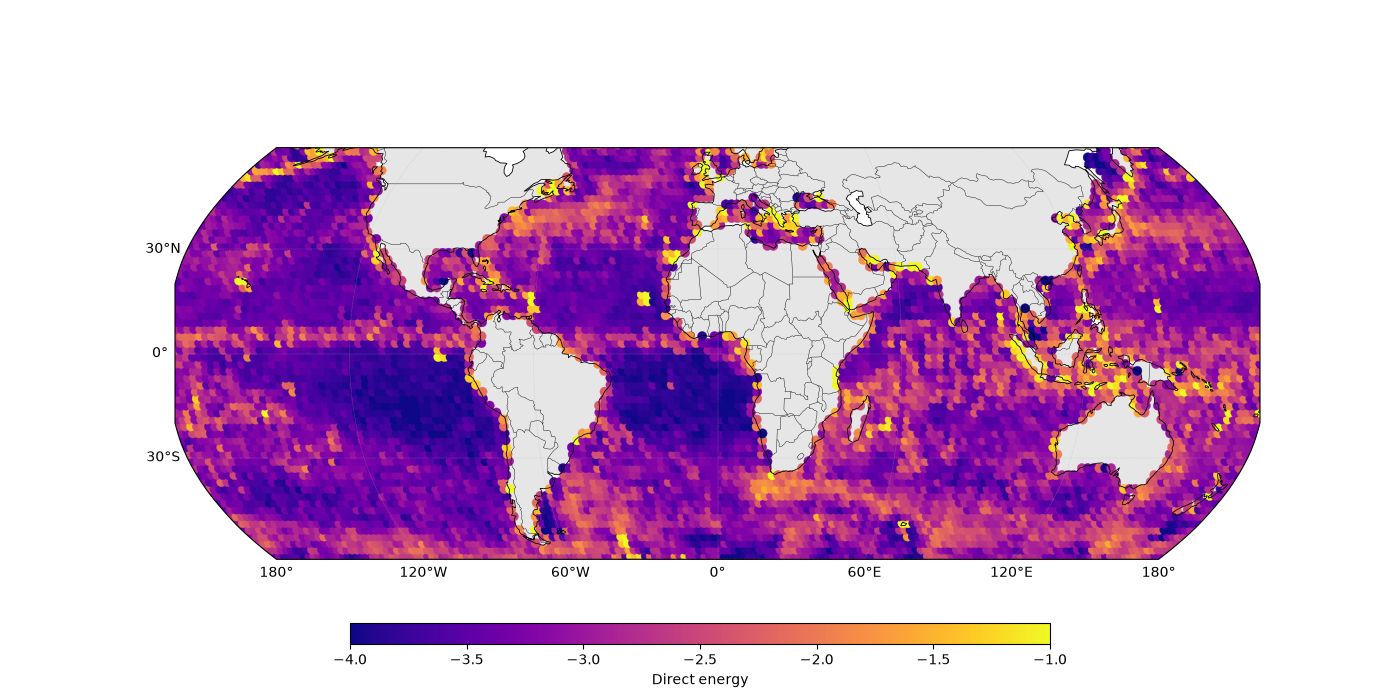

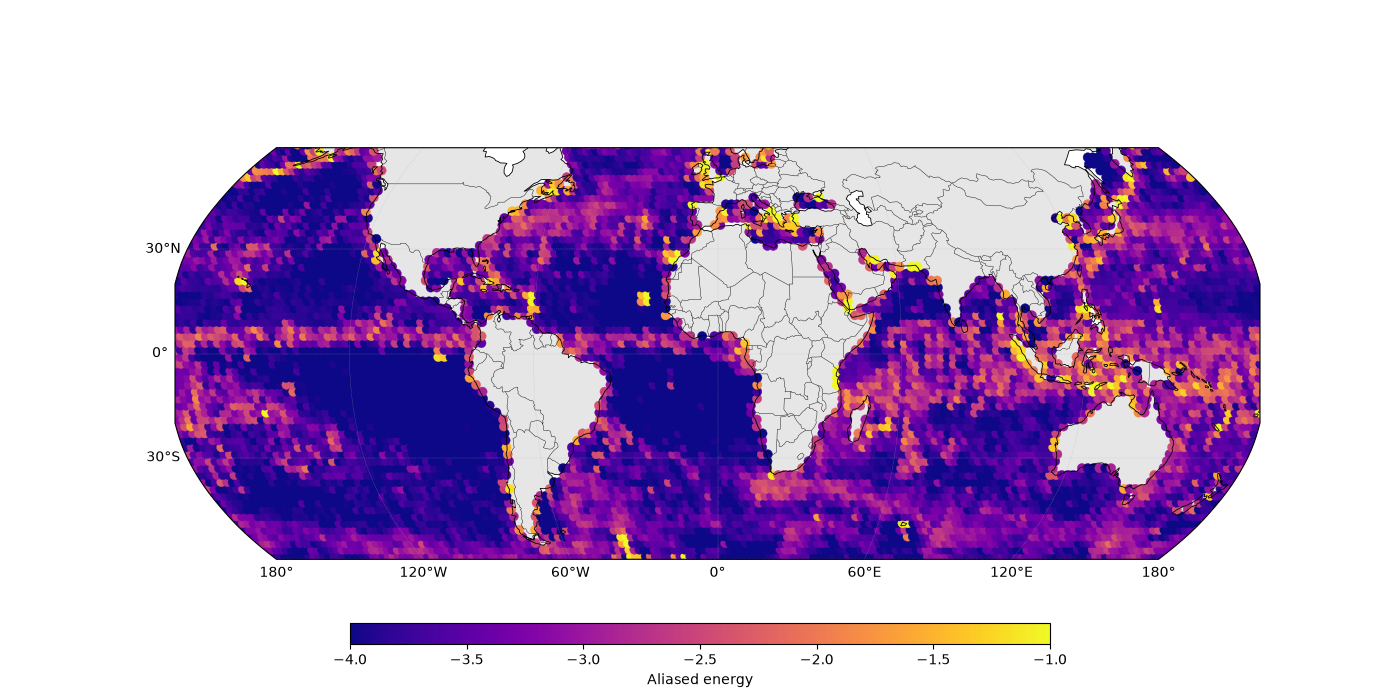

In [11]:
LON_MIN, LON_MAX = 0., 360.
LAT_MIN, LAT_MAX = -60, 60
fig, ax = plot_box(np.log10(ds_boxes["direct_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   label='Direct energy',
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                   vmin=-4,vmax=-1)
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
#plt.show()

fig, ax = plot_box(np.log10(ds_boxes["aliased_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   label='Aliased energy',
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                  vmin=-4,vmax=-1)
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())

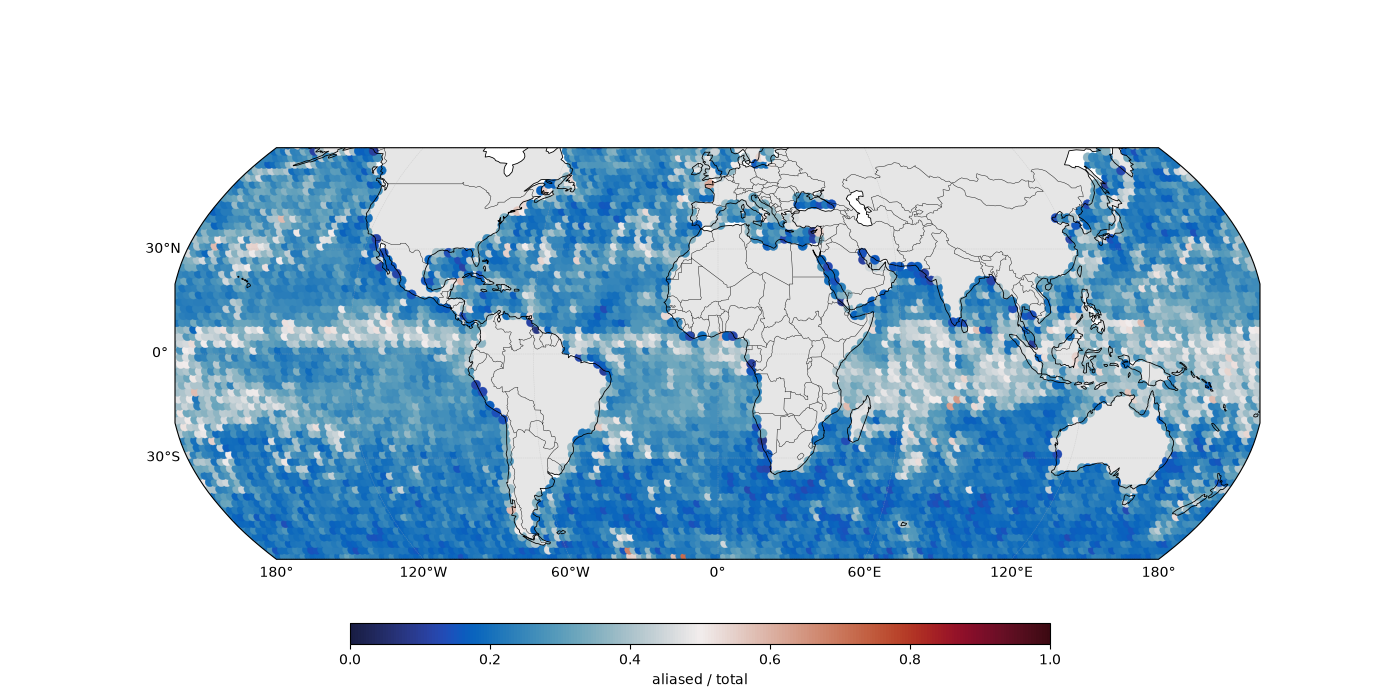

In [12]:
fig, ax = plot_box((ds_boxes["aliased_mean_psd"].integrate('wavenumber').values / ds_boxes["total_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   label='aliased / total',
                   cmap=cmocean.cm.balance, title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                  vmin=0,vmax=1.0)
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

(0.0, 1.0)

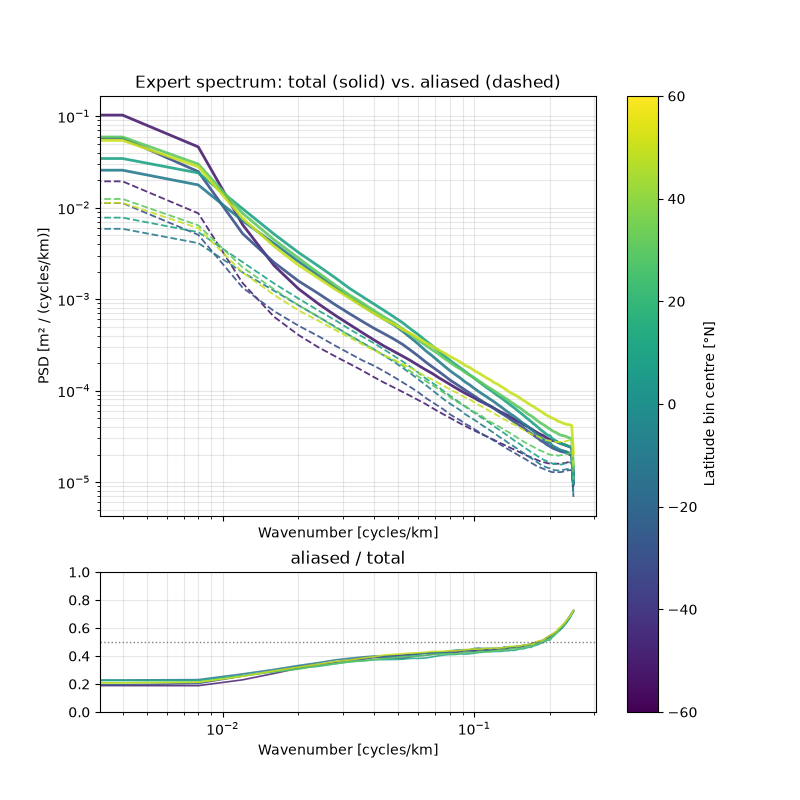

In [13]:
LAT_BIN_EDGES = np.arange(-60, 61, 20)  # adjust to the pass's latitude range

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

for lo, hi in zip(LAT_BIN_EDGES[:-1], LAT_BIN_EDGES[1:]):
    #recs = [ds_segments.where(ds_segments.swath==swath,drop=True) for swath in ('left', 'right')]
    recs = ds_segments.where((ds_segments.lat_mean<=hi) & (ds_segments.lat_mean>=lo),drop=True)
    if not recs:
        continue
    k = recs['wavenumber']
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    pred_stack = direct_stack + aliased_stack
    #meas_mean = np.nanmean([r['psd_meas'] for r in recs], axis=0)
    pred_mean = np.nanmedian(pred_stack, axis=0)
    aliased_mean = np.nanmedian(aliased_stack, axis=0)
    color = cmap(norm((lo + hi) / 2))
    axs[0].loglog(k, pred_mean, color=color, lw=2, alpha=0.9)
    axs[0].loglog(k, aliased_mean, color=color, lw=1.3, ls='--', alpha=0.9)
    axs[1].semilogx(k, aliased_mean / pred_mean, color=color, lw=1.2, alpha=0.85)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='Latitude bin centre [°N]')

axs[0].set_title('Expert spectrum: total (solid) vs. aliased (dashed)')
axs[0].set_xlabel('Wavenumber [cycles/km]')
axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_title('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].set_ylim(0,1)

/tmp/ipykernel_2353895/2534819893.py:14: RuntimeWarning: invalid value encountered in divide
  ratio = np.trapezoid(stack[:,idy], k[idy],dx=np.diff(k[idy])) / np.trapezoid(pred_stack[:,idy],k[idy],dx=np.diff(k[idy]))
/tmp/ipykernel_2353895/2534819893.py:14: RuntimeWarning: invalid value encountered in divide
  ratio = np.trapezoid(stack[:,idy], k[idy],dx=np.diff(k[idy])) / np.trapezoid(pred_stack[:,idy],k[idy],dx=np.diff(k[idy]))


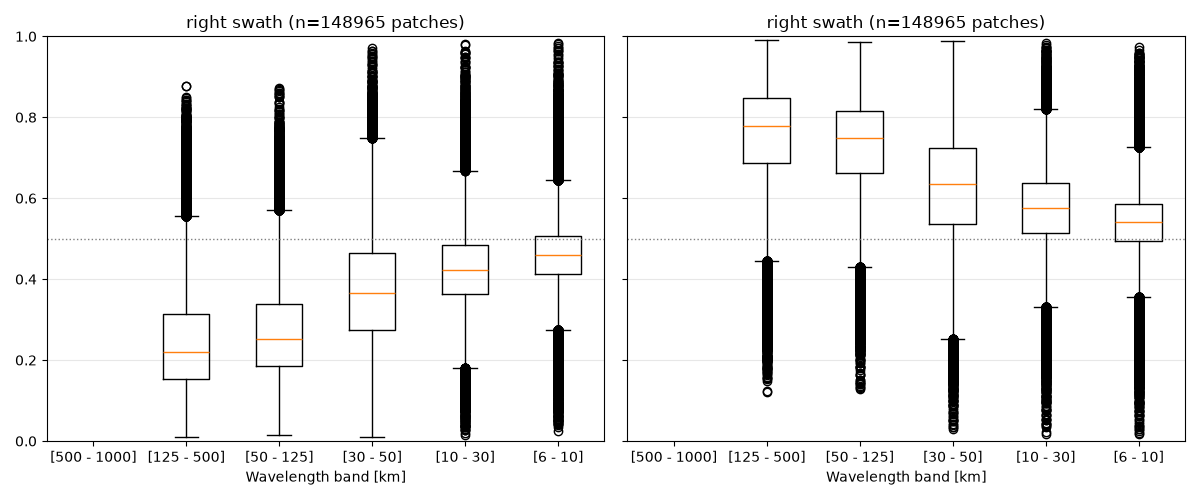

In [14]:
K_MIN = [1/1000, 1/500, 1/125, 1/50, 1/30, 1/10]
K_MAX = [1/500, 1/125,1/50, 1/30, 1/10, 1/6]

k = ds_segments['wavenumber'].values
direct_stack = ds_segments['direct_psd'].values
aliased_stack = ds_segments['aliased_psd'].values
pred_stack = ds_segments['total_psd'].values

fig, axs = plt.subplots(1,2,figsize=(12, 5), sharey=True)
for ax, stack in zip(axs, [aliased_stack, direct_stack]):
    data, labels = [], []
    for kmin,kmax in zip(K_MIN, K_MAX):
        idy = np.where((k<=kmax) & (k>=kmin))[0]
        ratio = np.trapezoid(stack[:,idy], k[idy],dx=np.diff(k[idy])) / np.trapezoid(pred_stack[:,idy],k[idy],dx=np.diff(k[idy]))
        data.append(ratio[np.isfinite(ratio)])
        labels.append(f'[{1/kmax:.0f} - {1/kmin:.0f}]')
    if data:
        ax.boxplot(data, tick_labels=labels, showfliers=True)
        ax.axhline(0.5, c='0.5', ls=':', lw=1)
        ax.set_title(f'{swath} swath (n={pred_stack.shape[0]} patches)')
        ax.set_xlabel('Wavelength band [km]')
        ax.grid(True, axis='y', alpha=0.3)
        ax.set_ylim(0,1.0)
#ax.set_ylabel('aliased / total PSD (predicted)')
fig.tight_layout()

/tmp/ipykernel_2353895/1024460349.py:2: RuntimeWarning: invalid value encountered in divide
  fig, ax = plot_box((ds_boxes["aliased_mean_psd"].sel(wavenumber=slice(kmin, kmax)).integrate('wavenumber').values / ds_boxes["total_mean_psd"].sel(wavenumber=slice(kmin, kmax)).integrate('wavenumber').values),


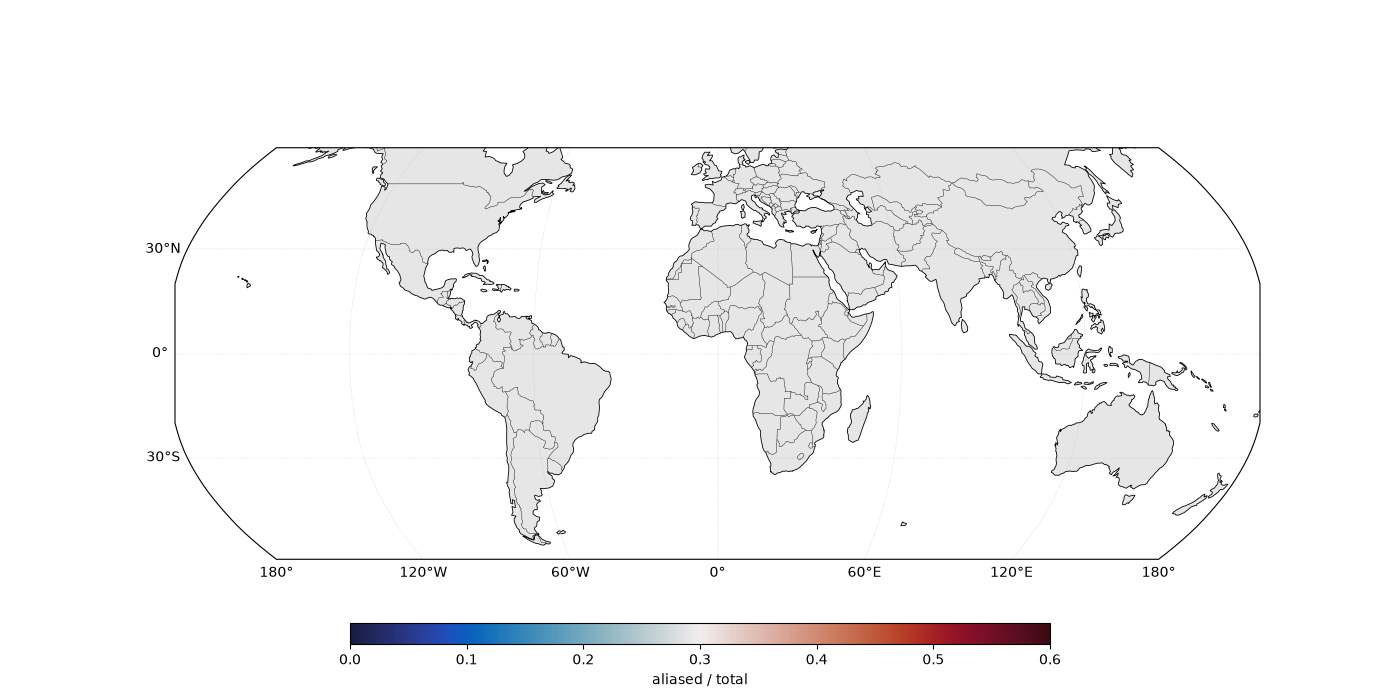

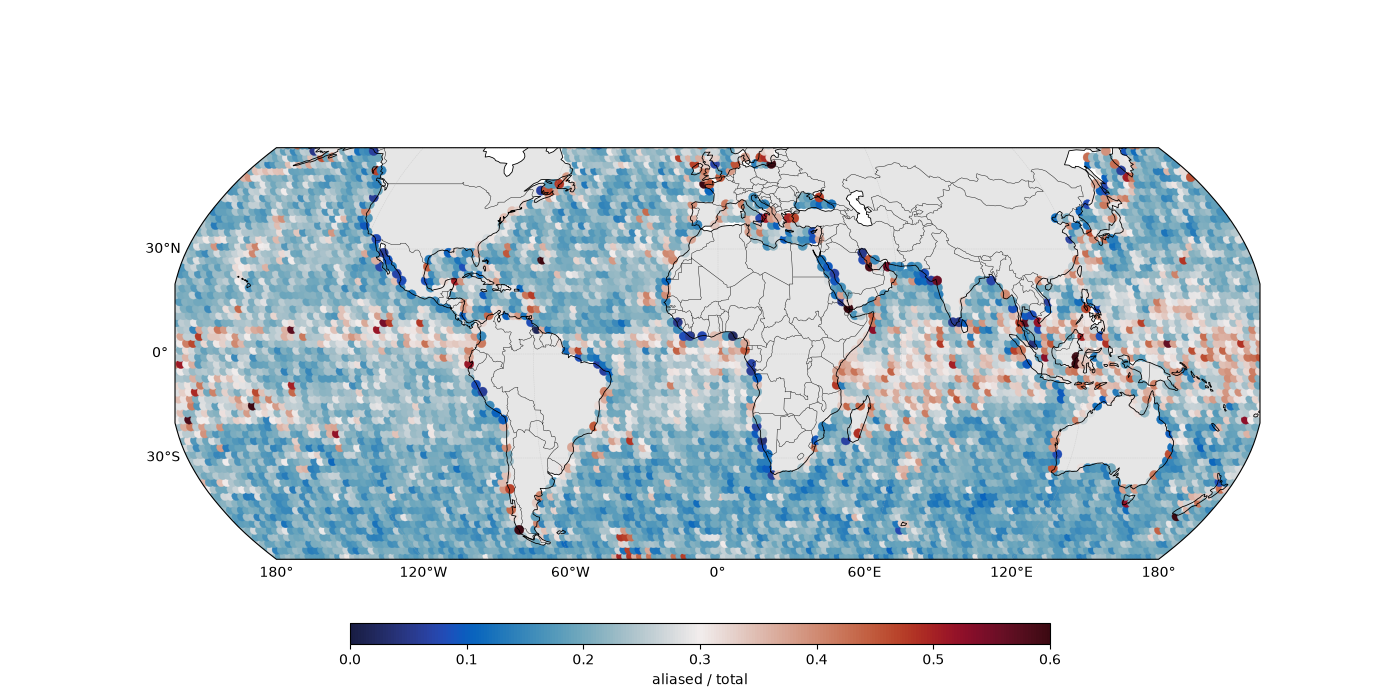

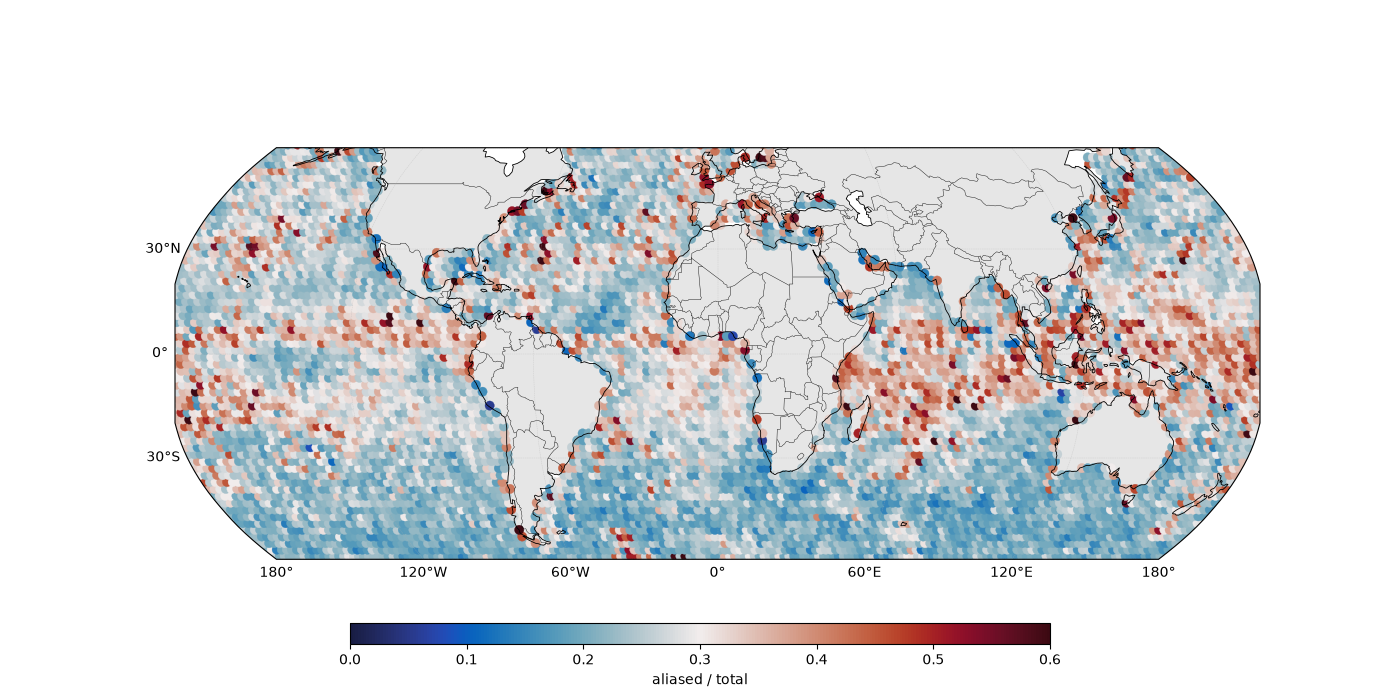

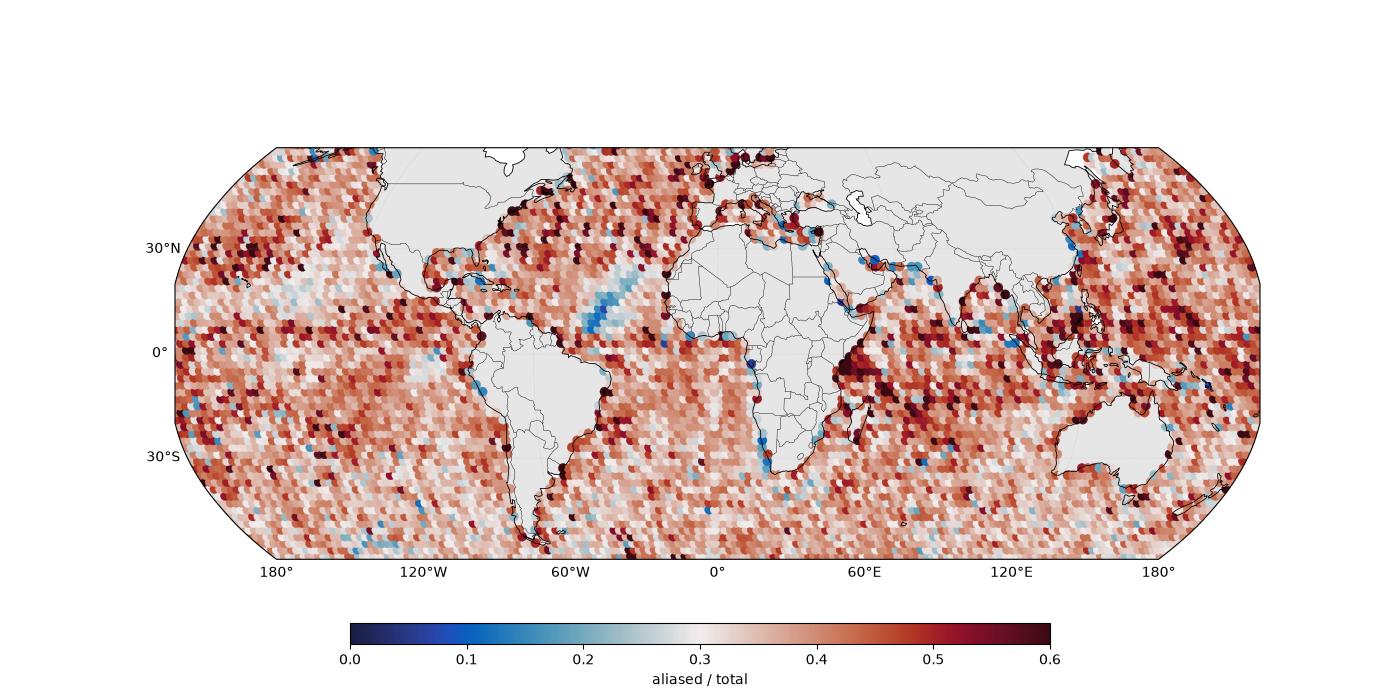

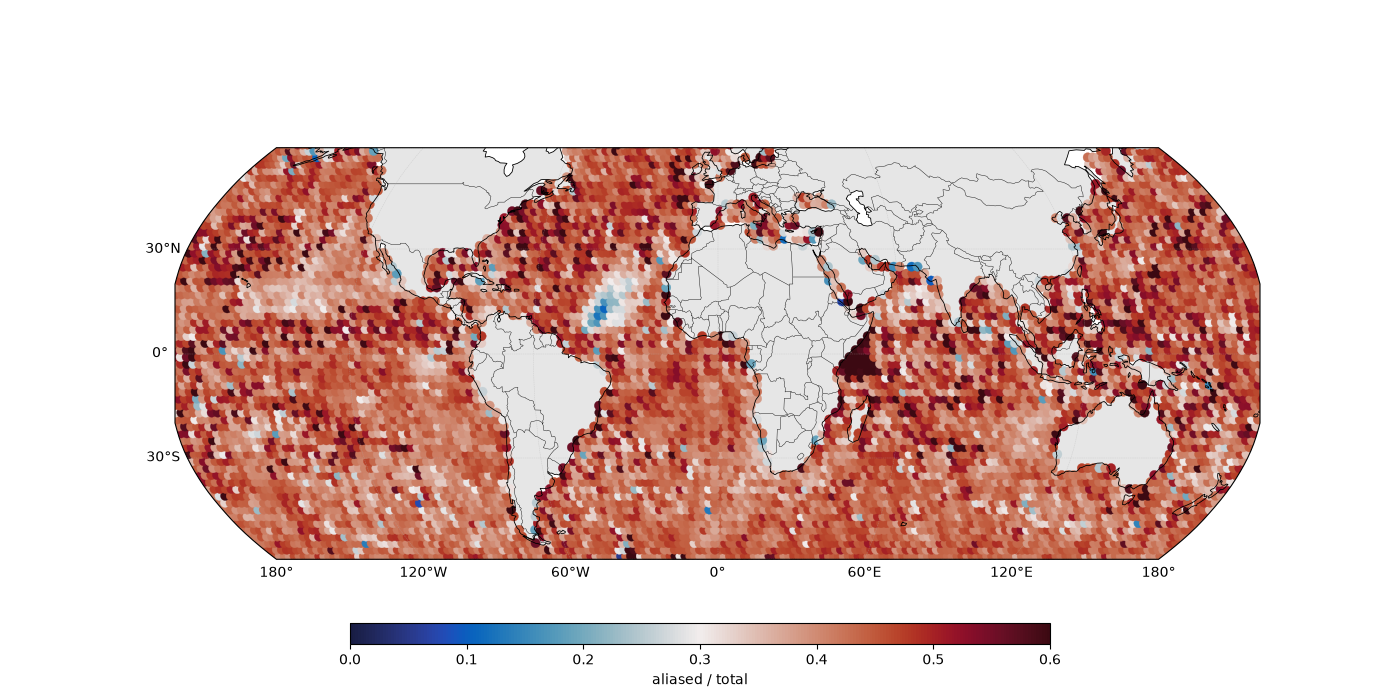

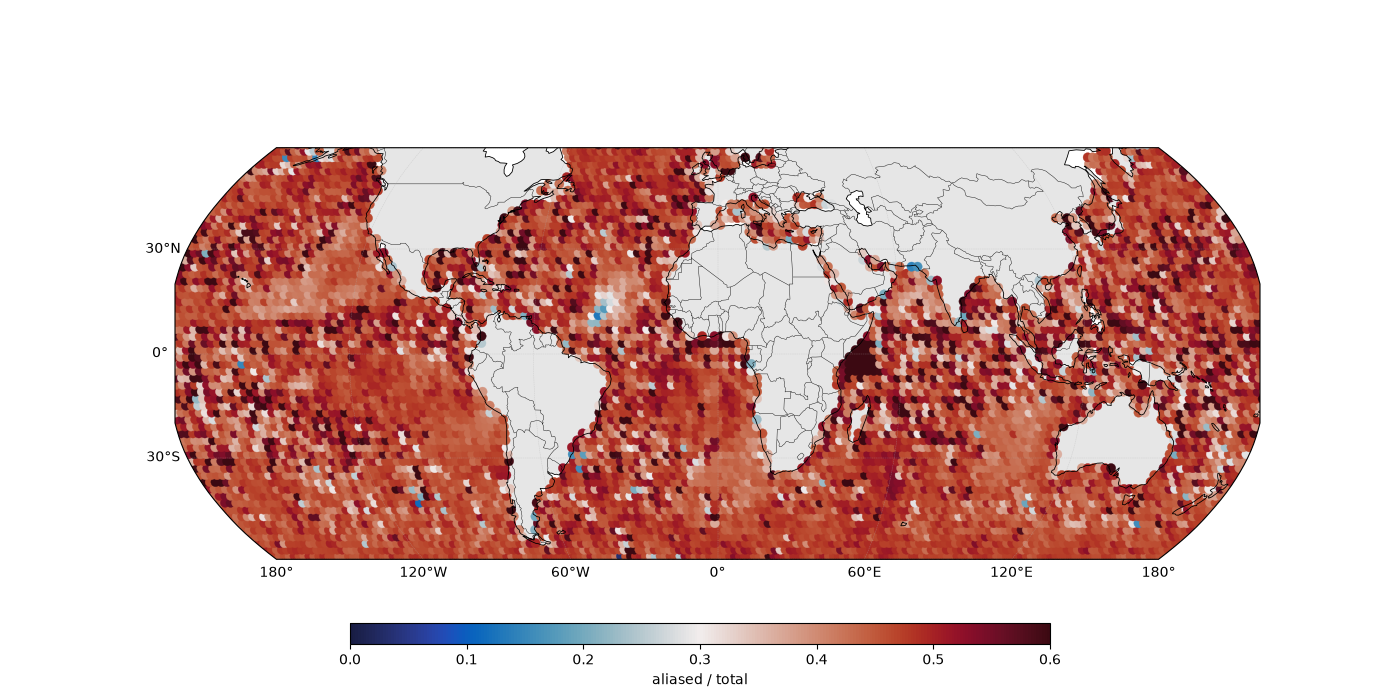

In [15]:
for kmin,kmax in zip(K_MIN, K_MAX):
    fig, ax = plot_box((ds_boxes["aliased_mean_psd"].sel(wavenumber=slice(kmin, kmax)).integrate('wavenumber').values / ds_boxes["total_mean_psd"].sel(wavenumber=slice(kmin, kmax)).integrate('wavenumber').values),
                       ds_boxes["lon_center"].values,
                       ds_boxes["lat_center"].values,
                       label='aliased / total',
                       cmap=cmocean.cm.balance, title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                      vmin=0,vmax=0.6)
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

## Flagging

(0.0, 1.0)

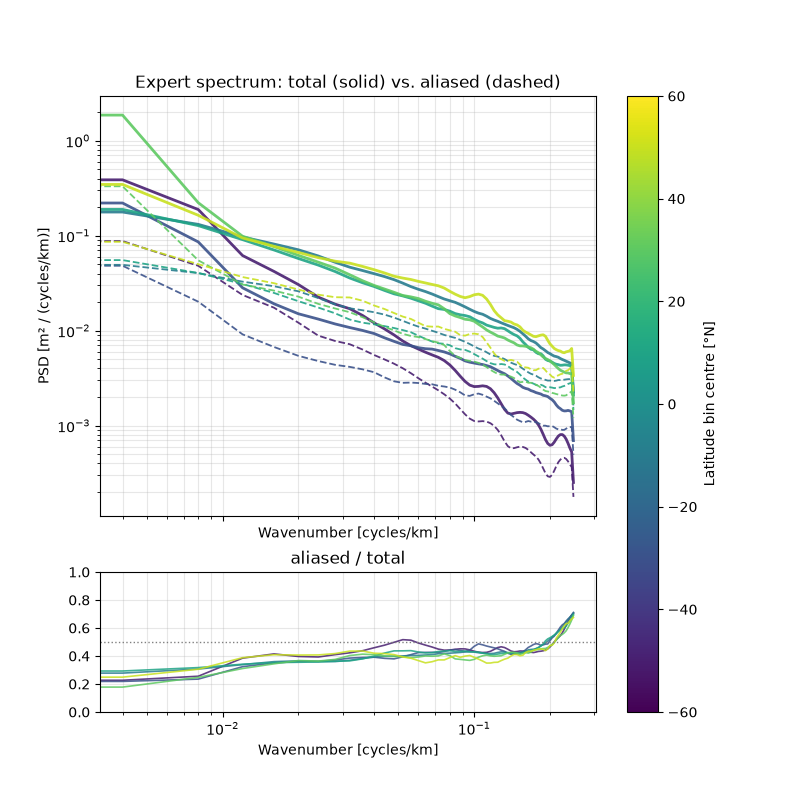

In [17]:
LAT_BIN_EDGES = np.arange(-60, 61, 20)  # adjust to the pass's latitude range

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

for lo, hi in zip(LAT_BIN_EDGES[:-1], LAT_BIN_EDGES[1:]):
    #recs = [ds_segments.where(ds_segments.swath==swath,drop=True) for swath in ('left', 'right')]
    recs = ds_segments.where((ds_segments.lat_mean<=hi) & (ds_segments.lat_mean>=lo),drop=True)
    if not recs:
        continue
    k = recs['wavenumber']
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    pred_stack = direct_stack + aliased_stack
    #meas_mean = np.nanmean([r['psd_meas'] for r in recs], axis=0)
    pred_mean = np.nanmean(pred_stack, axis=0)
    aliased_mean = np.nanmean(aliased_stack, axis=0)
    color = cmap(norm((lo + hi) / 2))
    axs[0].loglog(k, pred_mean, color=color, lw=2, alpha=0.9)
    axs[0].loglog(k, aliased_mean, color=color, lw=1.3, ls='--', alpha=0.9)
    axs[1].semilogx(k, aliased_mean / pred_mean, color=color, lw=1.2, alpha=0.85)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='Latitude bin centre [°N]')

axs[0].set_title('Expert spectrum: total (solid) vs. aliased (dashed)')
axs[0].set_xlabel('Wavenumber [cycles/km]')
axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_title('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].set_ylim(0,1)

In [18]:
recs = ds_segments.where((ds_segments.lat_mean<=20) & (ds_segments.lat_mean>=0),drop=True)

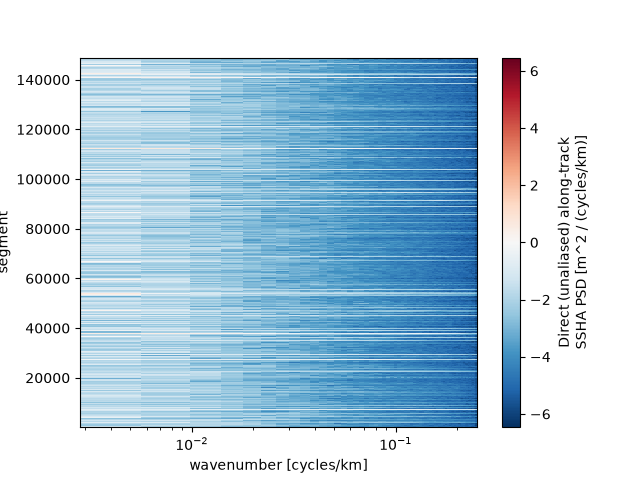

In [19]:
np.log10(recs.direct_psd.isel(wavenumber=slice(1,None))).sortby('segment').plot(x='wavenumber',y='segment',xscale='log')

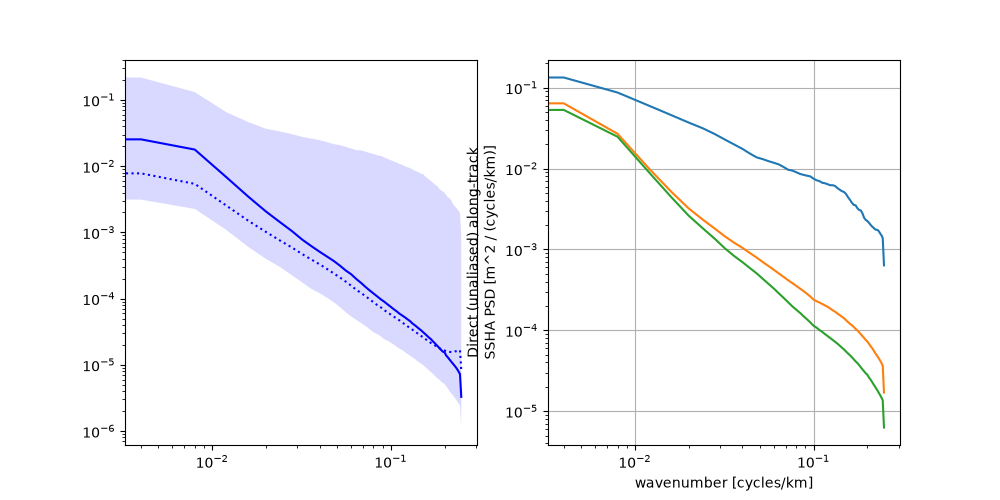

In [20]:
c = 'b'
fig,axs = plt.subplots(1,2,figsize=(10,5))

direct_median = np.nanmedian(recs['direct_psd'], axis=0)
direct_lo, direct_hi = np.nanpercentile(recs['direct_psd'], [5, 95], axis=0)
aliased_median = np.nanmedian(recs['aliased_psd'], axis=0)

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
#ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
ax.loglog(k, direct_median, c=c, lw=1.5, ls='-', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')

ax=axs[1]

recs['direct_psd'].mean('segment').plot(ax=ax,xscale='log',yscale='log')
recs['direct_psd'].where(recs['direct_psd'].sel(wavenumber=0.1,method='nearest')<5e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
recs['direct_psd'].where(recs['direct_psd'].sel(wavenumber=0.1,method='nearest')<1e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
ax.grid()

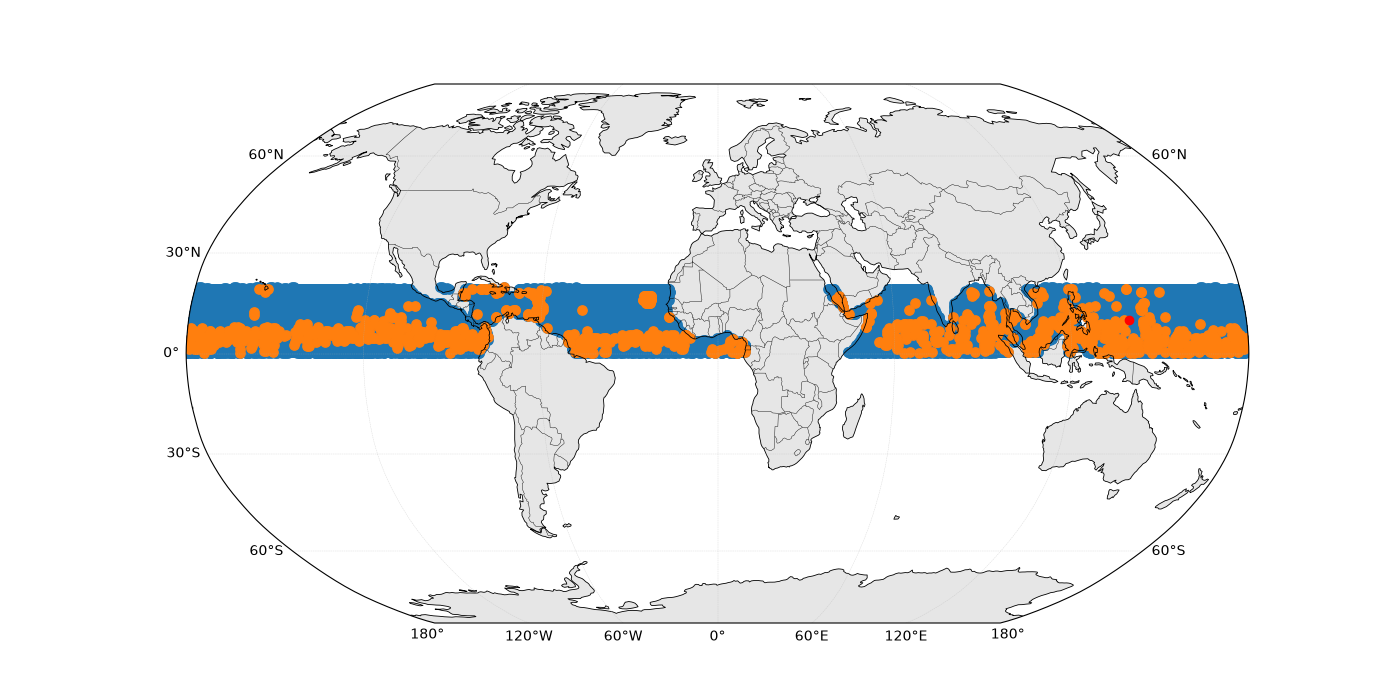

In [21]:
fig = plt.figure(figsize=(14,7))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}
ax.scatter(recs['lon_mean'], recs['lat_mean'], transform = ccrs.PlateCarree(), s=45)
r = recs.where(recs['direct_psd'].sel(wavenumber=0.1,method='nearest')>1e-2)
ax.scatter(r['lon_mean'], r['lat_mean'], transform = ccrs.PlateCarree(), s=45)
ax.scatter(140,10,c='r', transform = ccrs.PlateCarree())

In [91]:
dlat_max, dlon_max = 0.5, 0.5
lat_mean, lon_mean = 10, 140
r = recs.where((recs.lat_mean>=lat_mean-dlat_max) & (recs.lat_mean<=lat_mean+dlat_max)&(recs.lon_mean>=lon_mean-dlon_max) & (recs.lon_mean<=lon_mean+dlon_max))


In [90]:
recs.lon_mean

<xarray.DataArray 'lon_mean' (segment: 30405)> Size: 243kB
array([122.03901962, 264.32162587,  59.24591745, ..., 118.85605473,
       120.18205999, 316.33231861], shape=(30405,))
Coordinates:
  * segment  (segment) int64 243kB 0 34 43 44 45 ... 15595 15601 15602 15619
Attributes:
    units:    degrees_east

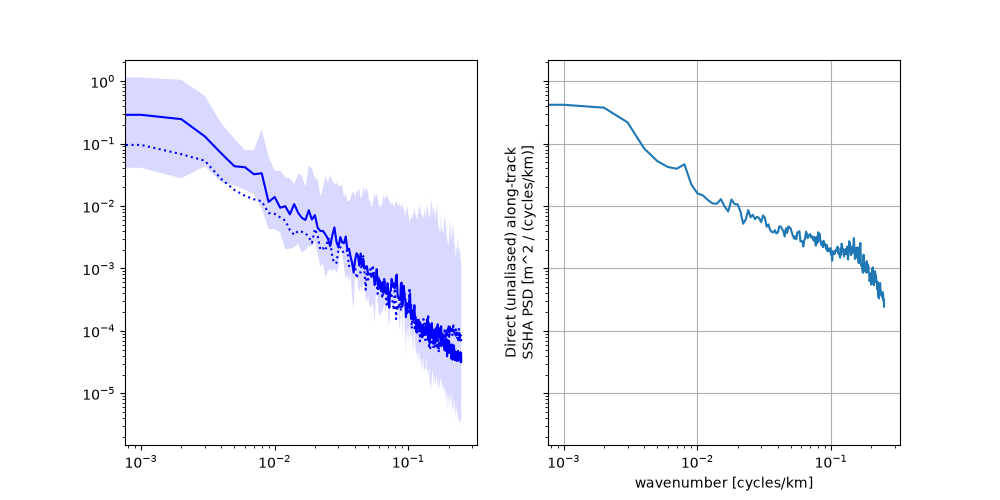

In [111]:
fig,axs = plt.subplots(1,2,figsize=(10,5),sharey=True)

direct_median = np.nanmedian(r['direct_psd'], axis=0)
direct_lo, direct_hi = np.nanpercentile(r['direct_psd'], [5, 95], axis=0)
aliased_median = np.nanmedian(r['aliased_psd'], axis=0)

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
#ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
ax.loglog(k, direct_median, c=c, lw=1.5, ls='-', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')

ax=axs[1]

r['direct_psd'].mean('segment').plot(ax=ax,xscale='log',yscale='log')
#r['direct_psd'].where(r['direct_psd'].sel(wavenumber=0.1,method='nearest')<5e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
#r['direct_psd'].where(r['direct_psd'].sel(wavenumber=0.1,method='nearest')<1e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
ax.grid()

In [101]:
r['direct_psd'].sel(wavenumber=0.1,method='nearest')

<xarray.DataArray 'direct_psd' (segment: 30405)> Size: 243kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(30405,))
Coordinates:
  * segment     (segment) int64 243kB 0 34 43 44 45 ... 15595 15601 15602 15619
    wavenumber  float64 8B 0.1
Attributes:
    long_name:  Direct (unaliased) along-track SSHA PSD
    units:      m^2 / (cycles/km)

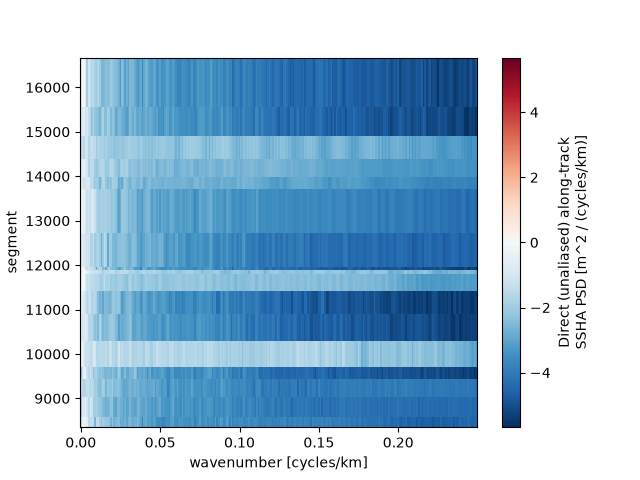

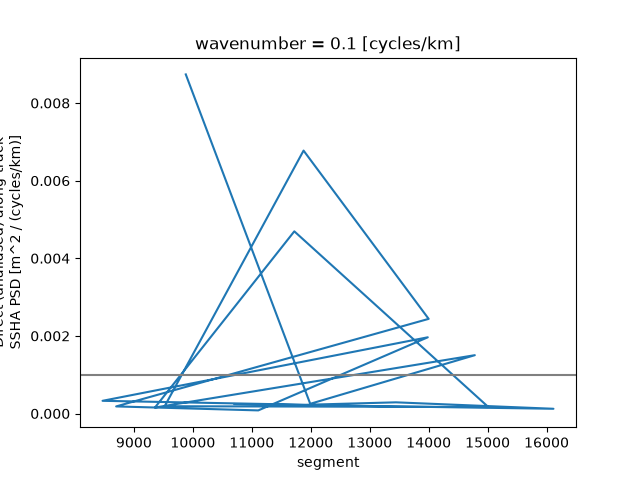

In [104]:
np.log10(r['direct_psd'].dropna('segment')).sortby('segment').plot()
plt.figure()
r['direct_psd'].sel(wavenumber=0.1,method='nearest').dropna('segment').plot()
plt.axhline(0.001,c='grey')

In [110]:
r.where(r['direct_psd'].dropna('segment').sel(wavenumber=0.1,method='nearest')<=1e-3).direct_psd.sortby('segment').plot()

ValueError: cannot reindex or align along dimension 'segment' because the (pandas) index has duplicate values

In [81]:
# Test monthly data

ds = xr.open_dataset(data_dir+'swot_aliased_202404.nc')
recs_01 = ds.where((ds.lat_mean<=lat_mean+dlat_max) & (ds.lat_mean>=lat_mean-dlat_max),drop=True)

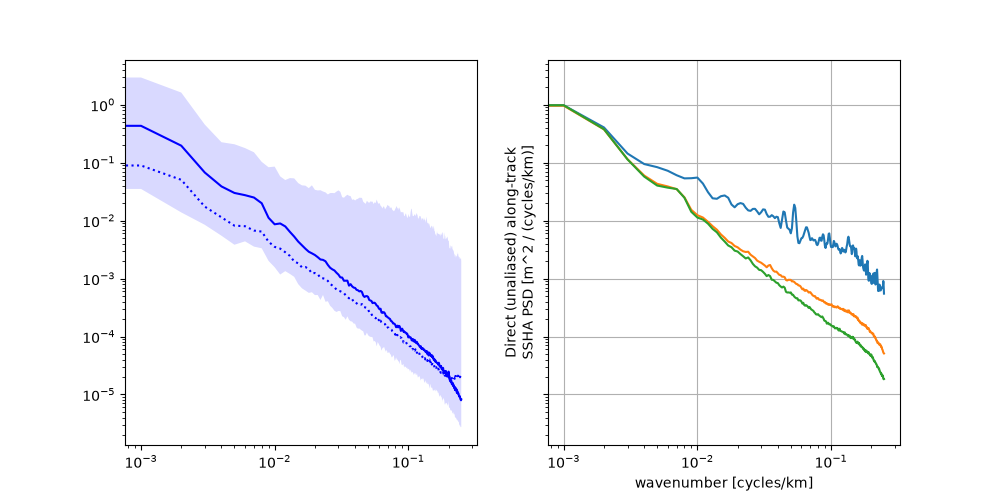

In [84]:
fig,axs = plt.subplots(1,2,figsize=(10,5),sharey=True)

direct_median = np.nanmedian(recs_01['direct_psd'], axis=0)
direct_lo, direct_hi = np.nanpercentile(recs_01['direct_psd'], [5, 95], axis=0)
aliased_median = np.nanmedian(recs_01['aliased_psd'], axis=0)

ax = axs[0]
ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
#ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
ax.loglog(k, direct_median, c=c, lw=1.5, ls='-', label=f'Expert - predicted (direct)')
ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased)')

ax=axs[1]

recs_01['direct_psd'].mean('segment').plot(ax=ax,xscale='log',yscale='log')
recs_01['direct_psd'].where(recs_01['direct_psd'].sel(wavenumber=0.1,method='nearest')<5e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
recs_01['direct_psd'].where(recs_01['direct_psd'].sel(wavenumber=0.1,method='nearest')<1e-3).mean('segment').plot(ax=ax,xscale='log',yscale='log')
ax.grid()

In [4]:
dk = np.diff(np.log10(ds_segments['wavenumber']))
#dpsd = np.diff(direct_stack,axis=1)

In [8]:
dpsd_mean = np.log10(ds_segments['direct_psd'].mean('segment')).diff('wavenumber')
dpsd_median = np.log10(ds_segments['direct_psd'].median('segment')).diff('wavenumber')

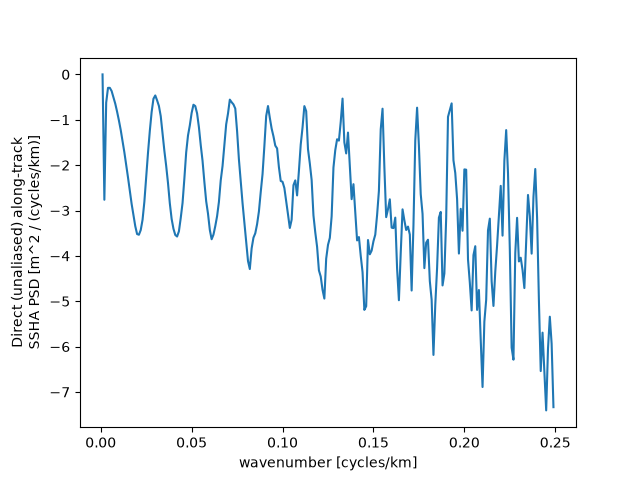

In [10]:
(dpsd_mean / dk).sel(wavenumber=slice()

In [ ]:
ds_segments_diff['dire]